# Netflix Dataset Analysis

A full analysis comabining a 9-panel KPI dashboard with a question-driven exploration section ---the kind of notebook that works well for both a portpholio piece and interview walkthroughs.

# Import required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

# Load  the dataset

In [4]:
df = pd.read_csv("Netflix Dataset.csv")
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [5]:
df.drop_duplicates(inplace=True)
df.shape

(7787, 11)

# Clean the missing values 

In [6]:
df["Director"] = df["Director"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
df["Rating"] = df["Rating"].fillna("Not Rated")
df["Cast"] = df["Cast"].fillna("Unknown")

# Feature Engineering

In [7]:
movies = df[df["Category"] == "Movie"].copy()
movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r'(\d+)')
    .astype(float)
)

df["Year"] = pd.to_datetime(
    df["Release_Date"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.year

df["Month"] = pd.to_datetime(
    df["Release_Date"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.month_name()

# Dashboard

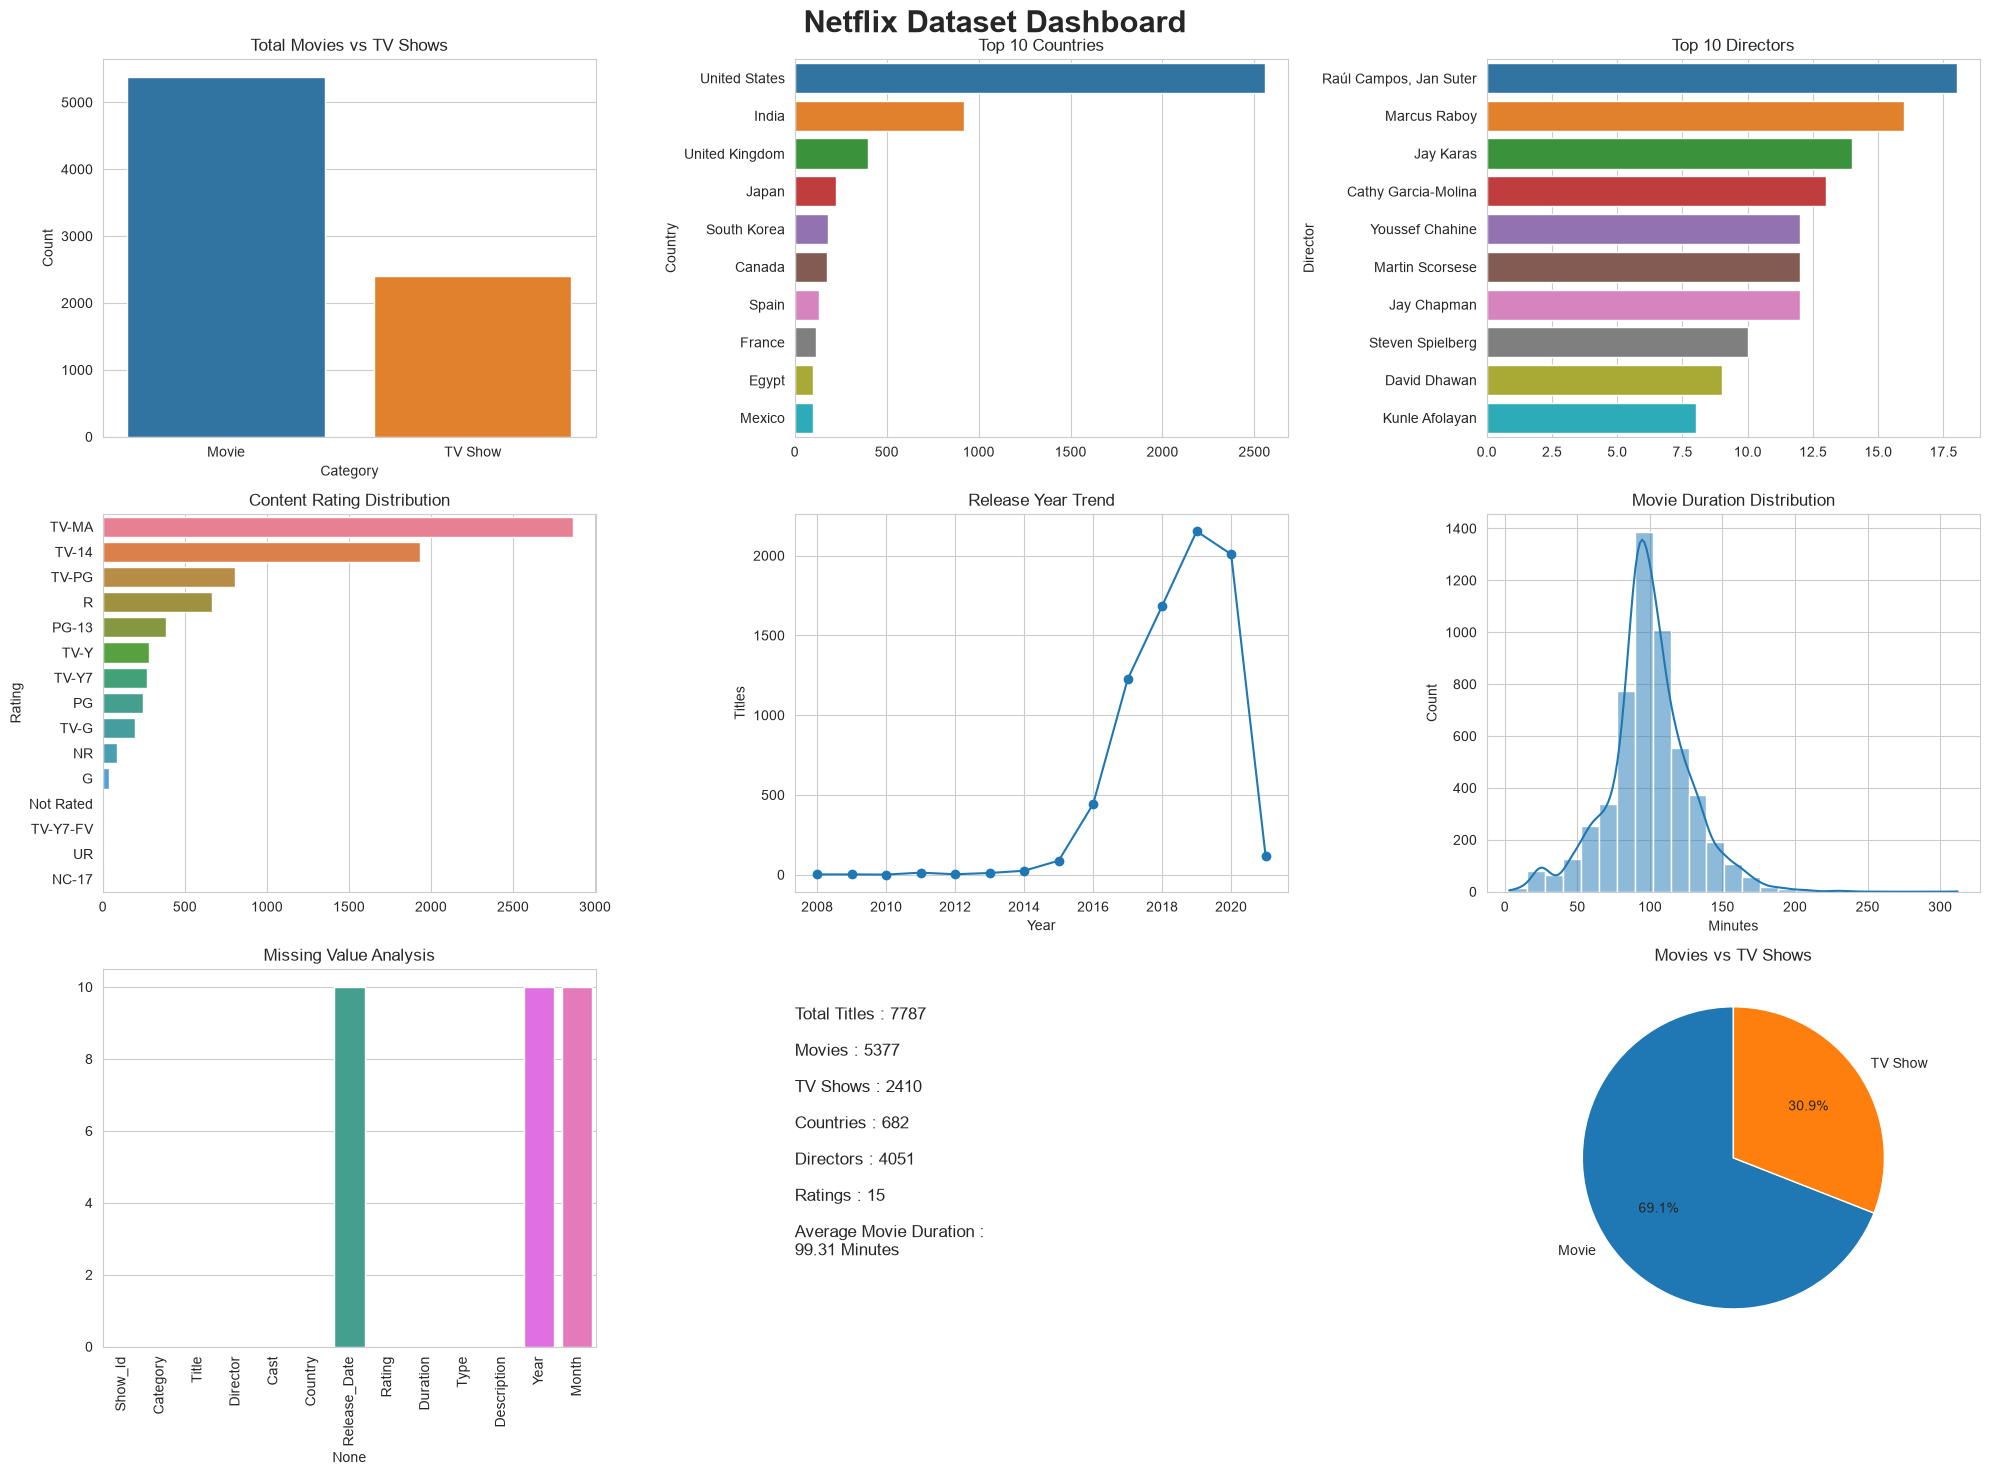

In [8]:
fig, ax = plt.subplots(3, 3, figsize=(20, 15))

# -------------------------------------------------------
# 1. Total Movies & TV Shows
# -------------------------------------------------------
category = df["Category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    hue=category.index,
    legend=False,
    ax=ax[0,0]
)

ax[0,0].set_title("Total Movies vs TV Shows")
ax[0,0].set_xlabel("Category")
ax[0,0].set_ylabel("Count")

# -------------------------------------------------------
# 2. Top Countries
# -------------------------------------------------------
top_country = df[df["Country"] != "Unknown"]["Country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    hue=top_country.index,
    legend=False,
    ax=ax[0,1]
)

ax[0,1].set_title("Top 10 Countries")

# -------------------------------------------------------
# 3. Top Directors
# -------------------------------------------------------
top_director = df[df["Director"] != "Unknown"]["Director"].value_counts().head(10)

sns.barplot(
    x=top_director.values,
    y=top_director.index,
    hue=top_director.index,
    legend=False,
    ax=ax[0,2]
)

ax[0,2].set_title("Top 10 Directors")

# -------------------------------------------------------
# 4. Content Rating Distribution
# -------------------------------------------------------
rating = df["Rating"].value_counts()

sns.barplot(
    x=rating.values,
    y=rating.index,
    hue=rating.index,
    legend=False,
    ax=ax[1,0]
)

ax[1,0].set_title("Content Rating Distribution")

# -------------------------------------------------------
# 5. Release Year Trend
# -------------------------------------------------------
release = df["Year"].value_counts().sort_index()

ax[1,1].plot(
    release.index,
    release.values,
    marker="o"
)

ax[1,1].set_title("Release Year Trend")
ax[1,1].set_xlabel("Year")
ax[1,1].set_ylabel("Titles")

# -------------------------------------------------------
# 6. Movie Duration Distribution
# -------------------------------------------------------
sns.histplot(
    movies["Minutes"],
    bins=25,
    kde=True,
    ax=ax[1,2]
)

ax[1,2].set_title("Movie Duration Distribution")

# -------------------------------------------------------
# 7. Missing Value Analysis
# -------------------------------------------------------
missing = df.isnull().sum()

sns.barplot(
    x=missing.index,
    y=missing.values,
    hue=missing.index,
    legend=False,
    ax=ax[2,0]
)

ax[2,0].tick_params(axis='x', rotation=90)
ax[2,0].set_title("Missing Value Analysis")

# -------------------------------------------------------
# 8. Dataset Summary
# -------------------------------------------------------
ax[2,1].axis("off")

summary = f"""
Total Titles : {len(df)}

Movies : {len(df[df['Category']=='Movie'])}

TV Shows : {len(df[df['Category']=='TV Show'])}

Countries : {df['Country'].nunique()}

Directors : {df['Director'].nunique()}

Ratings : {df['Rating'].nunique()}

Average Movie Duration :
{round(np.mean(movies['Minutes']),2)} Minutes
"""

ax[2,1].text(
    0,
    0.95,
    summary,
    fontsize=12,
    verticalalignment="top"
)

# -------------------------------------------------------
# 9. Movies vs TV Shows Pie Chart
# -------------------------------------------------------
ax[2,2].pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

ax[2,2].set_title("Movies vs TV Shows")

plt.suptitle(
    "Netflix Dataset Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Question Section

Qestion 1:Find the total number of movies and TV shows.

In [9]:
total_movies = df[df["Category"] == "Movie"].shape[0]
total_tvshows = df[df["Category"] == "TV Show"].shape[0]

print("Total Movies :", total_movies)
print("Total TV Shows :", total_tvshows)

Total Movies : 5377
Total TV Shows : 2410


Question 2:Identify the percentage of Movies vs TV Shows

In [10]:
category_percent = (df["Category"].value_counts(normalize=True) * 100).round(2)
print(category_percent)

Category
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64


Question 3:Find the top 10 countries producing Netflix content

In [11]:
top_10_countries = df[df["Country"] != "Unknown"]["Country"].value_counts().head(10)
print(top_10_countries)

Country
United States     2555
India              923
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Mexico             100
Name: count, dtype: int64


Question 4: Determine which director has directed the highest number of titles.

In [12]:
top_director = df[df["Director"] != "Unknown"]["Director"].value_counts().head(1)
print(top_director)

Director
Raúl Campos, Jan Suter    18
Name: count, dtype: int64


Question 5: Find the most common content rating.

In [13]:
most_common_rating = df["Rating"].mode()[0]
print("Most Common Rating :", most_common_rating)

Most Common Rating : TV-MA


Question 6: Analyze content released over the years.

In [14]:
release_per_year = df["Year"].value_counts().sort_index()
print(release_per_year)

Year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2153
2020.0    2009
2021.0     117
Name: count, dtype: int64


Question 7: Identify the year with the highest number of releases.

In [15]:
peak_year = df["Year"].value_counts().idxmax()
peak_count = df["Year"].value_counts().max()

print("Peak Release Year :", int(peak_year))
print("Number of Releases :", peak_count)

Peak Release Year : 2019
Number of Releases : 2153


**Question 8:** Find the longest movie available on Netflix.

In [16]:
longest_movie = movies.loc[movies["Minutes"].idxmax()]

print("Title :", longest_movie["Title"])
print("Duration :", longest_movie["Duration"])

Title : Black Mirror: Bandersnatch
Duration : 312 min


**Question 9:** Calculate the average movie duration.

In [17]:
average_duration = movies["Minutes"].mean()
print("Average Movie Duration :", round(average_duration, 2), "Minutes")

Average Movie Duration : 99.31 Minutes


**Question 10:** Find the most frequently appearing actor.

In [18]:
top_actor = (
    df["Cast"]
    .replace("Unknown", np.nan)
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(1)
)

print(top_actor)

Cast
Anupam Kher    42
Name: count, dtype: int64


**Question 11:** Analyze the distribution of content ratings by category.

In [19]:
rating_category = pd.crosstab(df["Category"], df["Rating"])
print(rating_category)

Rating     G  NC-17  NR  Not Rated   PG  PG-13    R  TV-14  TV-G  TV-MA  \
Category                                                                  
Movie     39      3  79          5  247    386  663   1272   111   1845   
TV Show    0      0   5          2    0      0    2    659    83   1018   

Rating    TV-PG  TV-Y  TV-Y7  TV-Y7-FV  UR  
Category                                    
Movie       505   117     95         5   5  
TV Show     301   163    176         1   0  


**Question 12:** Find the countries producing both Movies and TV Shows.

In [20]:
country_category = pd.crosstab(df["Country"], df["Category"])

both = country_category[
    (country_category["Movie"] > 0) &
    (country_category["TV Show"] > 0)
]

print(both)

Category                                  Movie  TV Show
Country                                                 
Argentina                                    34       16
Argentina, Spain                              7        1
Australia                                    37       46
Australia, Canada                             1        1
Australia, United States                      7        3
...                                         ...      ...
United States, Russia                         2        1
United States, Sweden                         2        1
United States, United Kingdom                30        7
United States, United Kingdom, Australia      3        1
Unknown                                     230      277

[93 rows x 2 columns]


**Question 13:** Determine which month has the highest number of releases.

In [21]:
month_release = df["Month"].value_counts()

print(month_release)
print("\nHighest Release Month :", month_release.idxmax())
print("Number of Releases :", month_release.max())

Month
December     833
October      785
January      757
November     738
March        669
September    619
August       618
April        601
July         600
May          543
June         542
February     472
Name: count, dtype: int64

Highest Release Month : December
Number of Releases : 833


**Question 14:** Calculate the percentage of missing values in each column.

In [22]:
missing_percentage = ((df.isnull().sum() / len(df)) * 100).round(2)
print(missing_percentage)

Show_Id         0.00
Category        0.00
Title           0.00
Director        0.00
Cast            0.00
Country         0.00
Release_Date    0.13
Rating          0.00
Duration        0.00
Type            0.00
Description     0.00
Year            0.13
Month           0.13
dtype: float64


**Question 15:** Find the top 5 genres by number of titles.

In [23]:
top_genres = df["Type"].dropna().str.split(", ").explode().value_counts().head(5)
print(top_genres)

Type
International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1199
Documentaries              786
Name: count, dtype: int64
